# Análisis Exploratorio de Datos #



## 1. Definición del Problema ##
Se analizará a contionuación datos de los años 2024 y 2025 de las solicirides de medicamentos de alto costo, dispositivos y actos médicos.
El obtetivo es saber es que caracteristicas tienen las solictudes aprobadas
Agregar más info, info básica del data set..

## Paso 2: Recopilación de datos

> Dataset de [FNR Solicitudes](https://www.fnr.gub.uy/estadisticas-2024/)

In [3]:
from email.quoprimime import header_encode
!python -m pip install -r ../requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest


In [5]:
!python -m pip list

Package                   Version
------------------------- -----------
altair                    6.2.2
anyio                     4.14.2
asttokens                 3.0.2
attrs                     26.1.0
blinker                   1.9.0
certifi                   2026.7.22
charset-normalizer        3.5.1
click                     8.4.2
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.21
executing                 2.2.1
fonttools                 4.63.0
h11                       0.16.0
httptools                 0.8.0
idna                      3.18
ipykernel                 7.3.0
ipython                   9.16.1
ipython_pygments_lexers   1.1.1
itsdangerous              2.2.0
jedi                      0.20.0
Jinja2                    3.1.6
joblib                    1.5.3
jsonschema                4.26.0
jsonschema-specifications 2025.9.1
jupyter_client            8.9.1
jupyter_core     

### Importamos los datos y creamos el DataFrame ###

In [5]:
df = pd.read_csv("../data/raw/FNR_solicitudes_2024_2025.csv", encoding="latin1")
df

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solcitud,fecha_autorización,pac_enmascarado,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen
0,Acto Médico,ACTOS CARDIOLOGÍA,201,Cateterismo diagnóstico infantil,7/28/2025,AUTORIZADO,8/8/2025,8236731,1,M,CANELONES,Hospital Policial,ASSE,CANELONES,PUBLICO
1,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,5/7/2025,AUTORIZADO,5/8/2025,8119160,62,M,MONTEVIDEO,Hospital Español,ASSE,MONTEVIDEO,PUBLICO
2,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,7/2/2025,AUTORIZADO,7/7/2025,8098843,71,F,MONTEVIDEO,Hospital Pasteur,ASSE,MONTEVIDEO,PUBLICO
3,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/20/2025,AUTORIZADO,3/14/2025,8244840,56,M,ROCHA,Centro departamental de Rocha,ASSE,ROCHA,PUBLICO
4,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/27/2025,AUTORIZADO,3/5/2025,8708606,79,F,RIO NEGRO,Centro departamental de Rio Negro,ASSE,RIO NEGRO,PUBLICO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71870,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,03/06/2024,AUTORIZADO,20/06/2024,8216632,66,M,TACUAREMBO,COMTA IAMPP,IAMC,TACUAREMBO,PRIVADO
71871,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,21/06/2024,AUTORIZADO,04/07/2024,8110928,68,F,CANELONES,CASMU,IAMC,MONTEVIDEO,PRIVADO
71872,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,02/12/2024,AUTORIZADO,30/01/2025,8224793,42,M,LAVALLEJA,CAMDEL IAMPP,IAMC,LAVALLEJA,PRIVADO
71873,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,29/10/2024,AUTORIZADO,05/12/2024,8219763,63,M,MONTEVIDEO,Hospital Maciel,ASSE,MONTEVIDEO,PUBLICO


In [9]:
df.head()

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solcitud,fecha_autorización,pac_enmascarado,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen
0,Acto Médico,ACTOS CARDIOLOGÍA,201,Cateterismo diagnóstico infantil,7/28/2025,AUTORIZADO,8/8/2025,8236731,1,M,CANELONES,Hospital Policial,ASSE,CANELONES,PUBLICO
1,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,5/7/2025,AUTORIZADO,5/8/2025,8119160,62,M,MONTEVIDEO,Hospital Español,ASSE,MONTEVIDEO,PUBLICO
2,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,7/2/2025,AUTORIZADO,7/7/2025,8098843,71,F,MONTEVIDEO,Hospital Pasteur,ASSE,MONTEVIDEO,PUBLICO
3,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/20/2025,AUTORIZADO,3/14/2025,8244840,56,M,ROCHA,Centro departamental de Rocha,ASSE,ROCHA,PUBLICO
4,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/27/2025,AUTORIZADO,3/5/2025,8708606,79,F,RIO NEGRO,Centro departamental de Rio Negro,ASSE,RIO NEGRO,PUBLICO


## Paso 3:Análisis Descriptivo ##

Cantidad de filas y columnas del data set

In [8]:
df.shape

(71875, 15)

Obtenemos información sobre tipo de datos y valores nulos

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71875 entries, 0 to 71874
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   tipo_prestacion          71875 non-null  str  
 1   area_prestacion          71875 non-null  str  
 2   prestacion_cod           71875 non-null  int64
 3   prestacion_desc          71875 non-null  str  
 4   fecha_solicitud          71875 non-null  str  
 5   estado_solcitud          71875 non-null  str  
 6   fecha_autorización       68691 non-null  str  
 7   pac_enmascarado          71875 non-null  int64
 8   edad_años                71875 non-null  int64
 9   sexo                     71875 non-null  str  
 10  departamento_residencia  71875 non-null  str  
 11  prestador_salud          71875 non-null  str  
 12  prestador_tipo           71875 non-null  str  
 13  departamento_prestador   71875 non-null  str  
 14  prestador_origen         71875 non-null  str  
dtypes: int64(3), 

Se observan 2 columnas de fecha que están como tipo de dato texto, se corrigen a tipo de dato fecha para poder analizar correctamente, ver de covertir a fecha

Resumen de las columnas numericas

In [11]:
df.describe()

,prestacion_cod,pac_enmascarado,edad_años
count,71875.000000,7.187500e+04,71875.000000
mean,1558.465113,8.199454e+06,63.492257
std,1735.801892,1.176022e+05,17.540975
min,101.000000,7.778195e+06,-32.000000
25%,302.000000,8.178992e+06,56.000000
50%,1101.000000,8.230323e+06,67.000000
75%,2102.000000,8.247226e+06,75.000000
max,6007.000000,8.747240e+06,104.000000


### Observaciones ###
1. Existen un total de 71875 filas (solicitudes) y 15 columnas, entre las cuales encontramos el target o clase a predecir: Estado_Solicitud
2. Las variables no tienen valores nulos
3. Los datos cuentan con 3 características numéricas y 12 categóricas
4. En el resumen de las columnas numericas se puede apreciar que el mínimo de edad no es un valor correcto (-32)


## Paso 4: Limpieza de Datos ##

### Duplicados ###

Verifico si hay duplicados y la cantidad, encontrando 10 solicitudes duplicadas

In [34]:
df.duplicated().sum()

np.int64(10)

Reviso los registros duplicados:

In [12]:
df[df.duplicated(keep=False)]

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solcitud,fecha_autorización,pac_enmascarado,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen
11419,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,3/10/2025,NO AUTORIZADO,NaN,8227565,52,F,CANELONES,CASMU,IAMC,MONTEVIDEO,PRIVADO
11420,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,3/10/2025,NO AUTORIZADO,NaN,8227565,52,F,CANELONES,CASMU,IAMC,MONTEVIDEO,PRIVADO
11425,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,3/10/2025,NO AUTORIZADO,NaN,8259443,81,M,MONTEVIDEO,COSEM,IAMC,MONTEVIDEO,PRIVADO
11426,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,3/10/2025,NO AUTORIZADO,NaN,8259443,81,M,MONTEVIDEO,COSEM,IAMC,MONTEVIDEO,PRIVADO
32322,Acto Médico,ACTOS CARDIOLOGÍA,102,Cirugia cardiaca adultos,8/22/2025,NO AUTORIZADO,NaN,8260429,25,M,MONTEVIDEO,Hospital Maciel,ASSE,MONTEVIDEO,PUBLICO
32323,Acto Médico,ACTOS CARDIOLOGÍA,102,Cirugia cardiaca adultos,8/22/2025,NO AUTORIZADO,NaN,8260429,25,M,MONTEVIDEO,Hospital Maciel,ASSE,MONTEVIDEO,PUBLICO
48093,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,02/05/2024,AUTORIZADO,18/09/2024,8159471,59,F,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
48094,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,02/05/2024,AUTORIZADO,18/09/2024,8159471,59,F,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
48569,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,12/06/2024,NO AUTORIZADO,NaN,7904501,79,M,CANELONES,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
48570,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,12/06/2024,NO AUTORIZADO,NaN,7904501,79,M,CANELONES,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO


Creo un nuevo DataFrame adicional para analizar duplicados sin la columna Pac_Enmascarado


In [7]:
df_sin_id = df.drop("pac_enmascarado", axis=1)

Analizo los duplicados en este nuevo Data Frame

In [15]:
df_sin_id.duplicated().sum()

np.int64(87)

Visualizo los nuevos duplicados

In [17]:
df_sin_id[df_sin_id.duplicated(keep=False)]

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solcitud,fecha_autorización,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen
1409,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,2/24/2025,AUTORIZADO,3/5/2025,69,M,RIVERA,CASMER IAMPP,IAMC,RIVERA,PRIVADO
1410,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,2/24/2025,AUTORIZADO,3/5/2025,69,M,RIVERA,CASMER IAMPP,IAMC,RIVERA,PRIVADO
1449,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,2/27/2025,AUTORIZADO,3/6/2025,61,M,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
1451,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,2/27/2025,AUTORIZADO,3/6/2025,61,M,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
5285,Acto Médico,ACTOS CARDIOLOGÍA,421,TAVI,6/3/2025,AUTORIZADO,6/6/2025,84,M,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66199,Otra Prestación,OTRA ÁREA,2801,Cirugía fetal,27/08/2024,AUTORIZADO,01/10/2024,35,F,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
66204,Otra Prestación,OTRA ÁREA,2801,Cirugía fetal,20/12/2024,AUTORIZADO,11/03/2025,43,F,MONTEVIDEO,COSEM,IAMC,MONTEVIDEO,PRIVADO
66205,Otra Prestación,OTRA ÁREA,2801,Cirugía fetal,20/12/2024,AUTORIZADO,11/03/2025,43,F,MONTEVIDEO,COSEM,IAMC,MONTEVIDEO,PRIVADO
71149,Otra Prestación,OTRA ÁREA,2801,Cirugía fetal,03/12/2024,AUTORIZADO,18/12/2024,25,F,CERRO LARGO,Centro auxiliar de Rio Branco,ASSE,CERRO LARGO,PUBLICO


Se eliminan a continuación los duplicados de todas las columnas, incluyendo la columna pac_enmascarado, ya que no se tiene forma de verificar sea un error, y es valido que sean solicitudes en la que coincidan todos los datos, pero sean distintos pacientes.

In [16]:
df = df.drop_duplicates()

Verifico nuevamente los duplicados para asegurarme fueron eliminados

In [19]:
df.duplicated().sum()

np.int64(0)

### Limpieza de datos: Eliminar información irrelevante
 ¿Son todas las características imprescindibles para realizar una predicción?
 Se analiza la información y se concluye que la única columna que no aporta a la predicción es Pac_enmascarado.
 Antes de eliminarla se analiza cuantas solicitudes para el mismo paciente existen.

In [27]:
solicitudes_por_paciente = (
df.groupby('pac_enmascarado')
.size()
.reset_index(name='cantidad_solicitudes'))
solicitudes_por_paciente["cantidad_solicitudes"].describe()

count    57661.000000
mean         1.246336
std          0.542713
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          7.000000
Name: cantidad_solicitudes, dtype: float64

La distribución de solicitudes por paciente muestra una alta concentración en una única solicitud. El 75% de los pacientes registró una sola solicitud durante el período analizado.

Se procede a eliminar la columna pac_enmascarado

In [28]:
df.drop(["pac_enmascarado"],
        axis=1,
        inplace=True)
df

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solcitud,fecha_autorización,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen
0,Acto Médico,ACTOS CARDIOLOGÍA,201,Cateterismo diagnóstico infantil,7/28/2025,AUTORIZADO,8/8/2025,1,M,CANELONES,Hospital Policial,ASSE,CANELONES,PUBLICO
1,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,5/7/2025,AUTORIZADO,5/8/2025,62,M,MONTEVIDEO,Hospital Español,ASSE,MONTEVIDEO,PUBLICO
2,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,7/2/2025,AUTORIZADO,7/7/2025,71,F,MONTEVIDEO,Hospital Pasteur,ASSE,MONTEVIDEO,PUBLICO
3,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/20/2025,AUTORIZADO,3/14/2025,56,M,ROCHA,Centro departamental de Rocha,ASSE,ROCHA,PUBLICO
4,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/27/2025,AUTORIZADO,3/5/2025,79,F,RIO NEGRO,Centro departamental de Rio Negro,ASSE,RIO NEGRO,PUBLICO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71870,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,03/06/2024,AUTORIZADO,20/06/2024,66,M,TACUAREMBO,COMTA IAMPP,IAMC,TACUAREMBO,PRIVADO
71871,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,21/06/2024,AUTORIZADO,04/07/2024,68,F,CANELONES,CASMU,IAMC,MONTEVIDEO,PRIVADO
71872,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,02/12/2024,AUTORIZADO,30/01/2025,42,M,LAVALLEJA,CAMDEL IAMPP,IAMC,LAVALLEJA,PRIVADO
71873,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,29/10/2024,AUTORIZADO,05/12/2024,63,M,MONTEVIDEO,Hospital Maciel,ASSE,MONTEVIDEO,PUBLICO


## Paso 5: Análisis Variables ##

### Análisis de Variables Univariantes Categóricas

Las variables categóricas del data frame son:
tipo_prestacion, area_prestacion, prestacion_cod, prestacion_desc	fecha_solicitud, estado_solcitud, fecha_autorización, edad_años, sexo	departamento_residencia, prestador_salud, prestador_tipo, departamento_prestador, prestador_origen

Ejemplo Histograma: variable categóricas

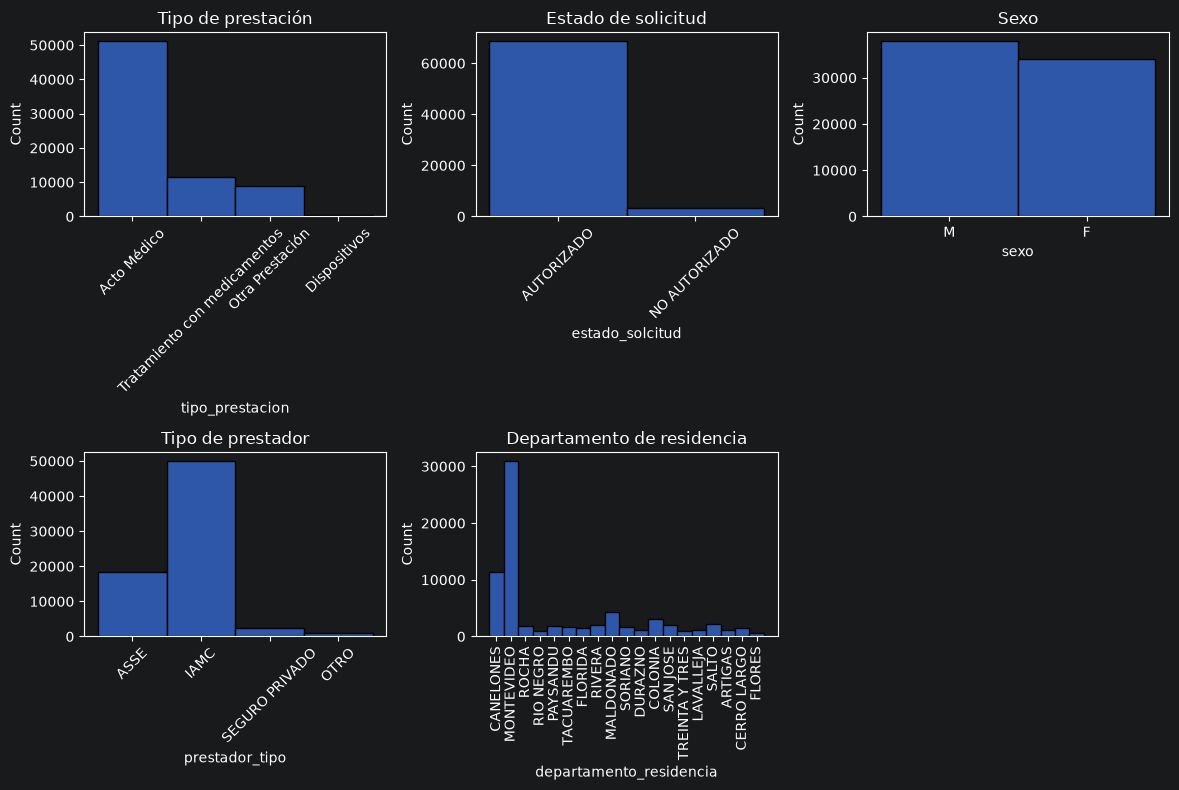

In [28]:
fig, axis = plt.subplots(2, 3, figsize=(12, 8))
sns.histplot(ax=axis[0, 0], data=df, x="tipo_prestacion")
axis[0, 0].set_title("Tipo de prestación")
axis[0, 0].tick_params(axis='x', rotation=45)
sns.histplot(ax=axis[0, 1], data=df, x="estado_solcitud")
axis[0, 1].set_title("Estado de solicitud")
axis[0, 1].tick_params(axis='x', rotation=45)
sns.histplot(ax=axis[0, 2], data=df, x="sexo")
axis[0, 2].set_title("Sexo")
sns.histplot(ax=axis[1, 0], data=df, x="prestador_tipo")
axis[1, 0].set_title("Tipo de prestador")
axis[1, 0].tick_params(axis='x', rotation=45)
sns.histplot(ax=axis[1, 1], data=df, x="departamento_residencia")
axis[1, 1].set_title("Departamento de residencia")
axis[1, 1].tick_params(axis='x', rotation=90)
plt.tight_layout()
axis[1, 2].set_visible(False)
plt.show()